###imports

In [ ]:
import zipfile
import os
import shutil
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Conv2D, MaxPooling2D, Flatten, Dropout,
                                     BatchNormalization, LeakyReLU,DepthwiseConv2D,ReLU,Add,GlobalAveragePooling2D,GlobalMaxPooling2D)
from sklearn.metrics import classification_report , confusion_matrix
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import AdamW ,Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
from tensorflow.keras.metrics import Accuracy, Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

###Extracting Dataset

In [ ]:
def extract_dataset() :
  zip_path = '/content/Teeth DataSet.zip'
  extract_path = ''
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)


In [ ]:
extract_dataset()

In [ ]:
train_ds_path = "/content/Teeth_Dataset/Training"
test_ds_path='/content/Teeth_Dataset/Testing'
val_ds_path='/content/Teeth_Dataset/Validation'

###Remove test incorrect files

In [ ]:
for dirpath, dirnames, filenames in os.walk(test_ds_path):
  for dir in dirnames :
    if dir in ["output","outputs","out"] :
      shutil.rmtree(os.path.join(test_ds_path,dir))

os.remove(os.path.join(test_ds_path,'output_image.jpg'))

###Load DataSet

In [ ]:
batch_size = 128
img_size = (224, 224)
train = tf.keras.utils.image_dataset_from_directory(
    train_ds_path,
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=img_size,
    shuffle=True
)
val = tf.keras.utils.image_dataset_from_directory(
    val_ds_path,
    labels='inferred',
    label_mode='int',
    batch_size=1,
    image_size=img_size,
    shuffle=False
)
test = tf.keras.utils.image_dataset_from_directory(
    test_ds_path,
    labels='inferred',
    label_mode='int',
    batch_size=1,
    image_size=img_size,
    shuffle=False
)

Found 3087 files belonging to 7 classes.
Found 1028 files belonging to 7 classes.
Found 1028 files belonging to 7 classes.


In [ ]:
class_to_index=dict()
for index,name in enumerate(train.class_names) :
  class_to_index[name]=index
print(class_to_index)

{'CaS': 0, 'CoS': 1, 'Gum': 2, 'MC': 3, 'OC': 4, 'OLP': 5, 'OT': 6}


### Visualization one Batch

Images batch shape: (128, 256, 256, 3)
Labels batch shape: (128,)


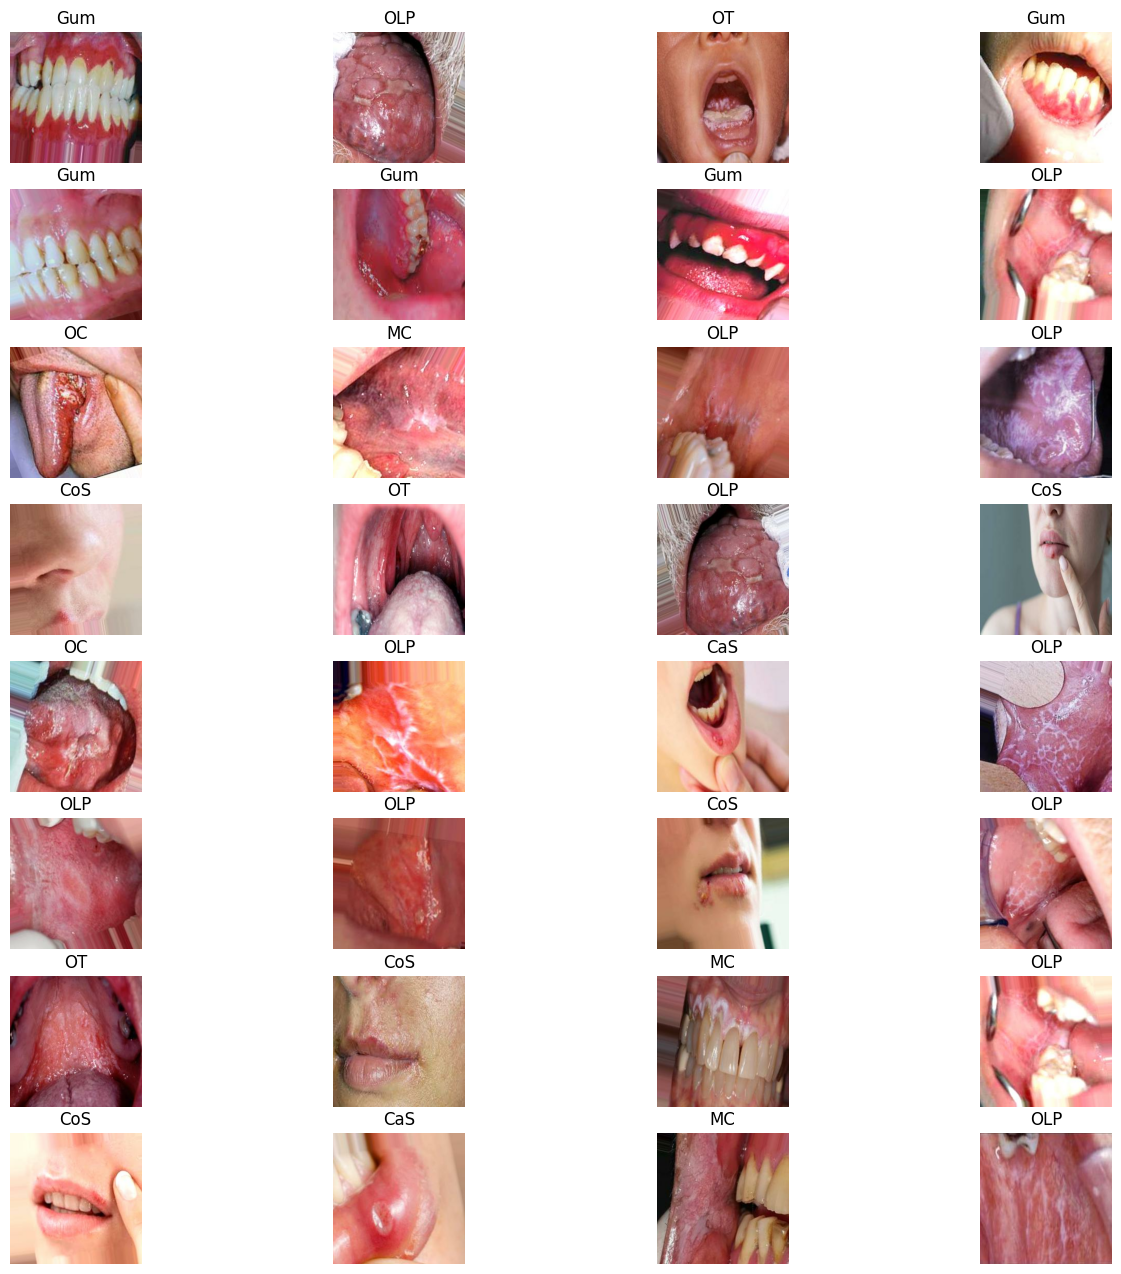

In [ ]:
for images, labels in train.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels.shape)
    plt.figure(figsize=(16, 16))
    for index in range(32) :
      ax = plt.subplot(8, 4, index+1)
      plt.imshow(images[index].numpy().astype("uint8"))
      plt.title(train.class_names[labels[index]])
      plt.axis("off")
    plt.show()

###Preprocessing

In [ ]:
normalization = tf.keras.layers.Rescaling(1./255)

train = train.map(lambda x, y: (normalization(x), y))
val = val.map(lambda x, y: (normalization(x), y))
test = test.map(lambda x, y: (normalization(x), y))

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomRotation(0.2),
])

In [ ]:
def augment_selected(x, y):
    condition = tf.reduce_any(tf.equal(y, [2, 4, 6]))

    return tf.cond(
        condition,
        lambda: (data_augmentation(x, training=True), y),
        lambda: (x, y)
    )
train_after_augmentation = train.map(augment_selected)

###Visualization

In [ ]:
distribute_classes=dict()
for dirpath, dirnames, filenames in os.walk(train_ds_path):
  for dir in dirnames :
    fulldir = os.path.join(train_ds_path,dir)
    distribute_classes[dir]= len(os.listdir(fulldir))
print(distribute_classes)

{'MC': 540, 'OC': 324, 'CaS': 480, 'CoS': 450, 'OT': 393, 'OLP': 540, 'Gum': 360}


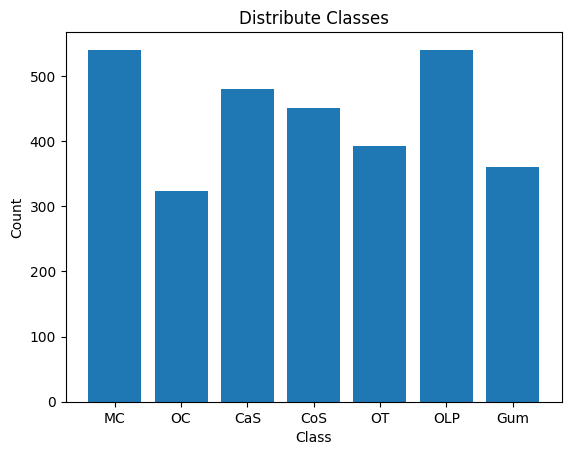

In [ ]:
plt.bar(distribute_classes.keys(),distribute_classes.values())
plt.title("Distribute Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

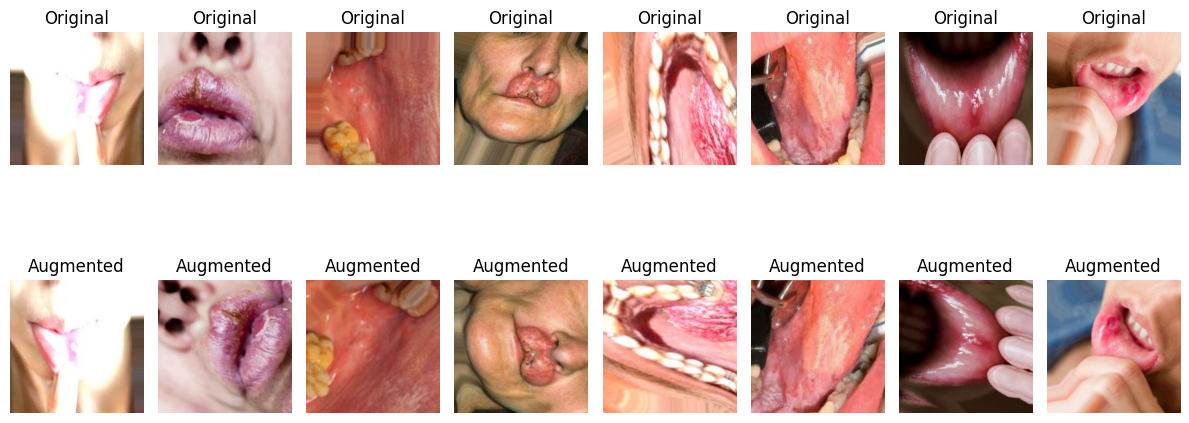

In [ ]:
for images, labels in train.take(1):
    plt.figure(figsize=(12, 6))

    for i in range(8):
        ax = plt.subplot(2, 8, i + 1)
        img = images[i]
        plt.imshow(tf.cast((img*255), tf.uint8))
        plt.title("Original")
        plt.axis("off")

        ax = plt.subplot(2, 8, i + 1 + 8)
        aug_img = data_augmentation(tf.expand_dims(img, 0))
        plt.imshow(tf.cast((aug_img[0]*255), tf.uint8))
        plt.title("Augmented")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


#Model

In [ ]:
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

for layer in base_model.layers[-3:]:
    layer.trainable = True

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),


    Dense(7, activation='softmax')
])

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
early_stopping= tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=20,
    mode="auto",
    restore_best_weights=True,
    verbose=1
)

In [ ]:
weight = {
    class_to_index[k]: 3087 / (7 * v)
    for k,v in distribute_classes.items()
}
print(weight)

{3: 0.8166666666666667, 4: 1.3611111111111112, 0: 0.91875, 1: 0.98, 6: 1.1221374045801527, 5: 0.8166666666666667, 2: 1.225}


In [ ]:
history=model.fit(train, epochs=150,validation_data=val ,
                  callbacks=[early_stopping],
                  verbose=1,class_weight=weight)

Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.3924 - loss: 1.7000 - val_accuracy: 0.3745 - val_loss: 1.8586
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 957ms/step - accuracy: 0.7837 - loss: 0.6795 - val_accuracy: 0.4416 - val_loss: 1.7853
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 911ms/step - accuracy: 0.9284 - loss: 0.3551 - val_accuracy: 0.6206 - val_loss: 1.7137
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 908ms/step - accuracy: 0.9773 - loss: 0.2107 - val_accuracy: 0.6916 - val_loss: 1.6282
Epoch 5/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 918ms/step - accuracy: 0.9925 - loss: 0.1232 - val_accuracy: 0.6897 - val_loss: 1.5518
Epoch 6/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 928ms/step - accuracy: 0.9980 - loss: 0.0795 - val_accuracy: 0.7656 - val_loss: 1.4449
Epoch 7/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 929ms/step - accuracy: 0.9999 - loss: 0.0495 - val_accuracy: 0.7967 - val_loss: 1.3279
Epoch 8/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 929ms/step - accuracy: 0.9994 - loss: 0.0396 - val

In [ ]:
loss, acc = model.evaluate(test, verbose=1)
print('Accuracy: {:5.2f}%'.format(100 * acc))
print('Loss: {:5.2f}'.format(loss))


1028/1028 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9904 - loss: 0.0409
Accuracy: 98.74%
Loss:  0.06


In [ ]:
pred = model.predict(test)

true_labels = np.concatenate([y for x, y in test], axis=0)

predicted_labels = np.argmax(pred, axis=1)

print(classification_report(true_labels, predicted_labels))

1028/1028 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       160
           1       1.00      1.00      1.00       149
           2       0.99      1.00      1.00       120
           3       0.99      0.97      0.98       180
           4       0.99      0.97      0.98       108
           5       0.97      0.98      0.98       180
           6       0.98      1.00      0.99       131

    accuracy                           0.99      1028
   macro avg       0.99      0.99      0.99      1028
weighted avg       0.99      0.99      0.99      1028



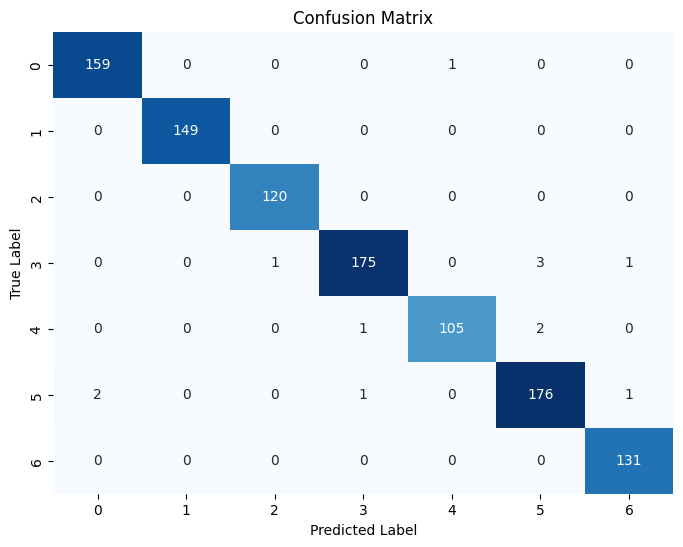

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save("teeth_classifier vgg16.h5")